# 01 - Data Validation + Preprocessing (FD001)

**Purpose:** Debug and prepare NASA C-MAPSS FD001 so the LSTM can learn non-constant RUL behavior.

**Inputs:** `data/raw/train_FD001.txt`, `data/raw/test_FD001.txt`, `data/raw/RUL_FD001.txt`

**Outputs:** processed arrays + scaler in `data/processed/` for training, evaluation, API, and frontend demo.

In [1]:
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "raw").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

SEQ_LEN = 30
RUL_CAP = 125

In [2]:
columns = ["unit_id", "cycle", "op_setting_1", "op_setting_2", "op_setting_3"] + [f"sensor_{i}" for i in range(1, 22)]

train_df = pd.read_csv(RAW_DIR / "train_FD001.txt", sep=r"\s+", header=None, names=columns)
test_df = pd.read_csv(RAW_DIR / "test_FD001.txt", sep=r"\s+", header=None, names=columns)
rul_df = pd.read_csv(RAW_DIR / "RUL_FD001.txt", sep=r"\s+", header=None, names=["final_rul"])

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("RUL rows:", len(rul_df))
train_df.head()

Train shape: (20631, 26)
Test shape: (13096, 26)
RUL rows: 100


,unit_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [3]:
drop_cols = [
    "op_setting_3",
    "sensor_1", "sensor_5", "sensor_6", "sensor_10",
    "sensor_16", "sensor_18", "sensor_19",
]

train_df = train_df.drop(columns=drop_cols).copy()
test_df = test_df.drop(columns=drop_cols).copy()

# Use only sensor channels as model inputs to match input_size=14.
feature_cols = [c for c in train_df.columns if c.startswith("sensor_")]
print("Input feature count:", len(feature_cols))
print(feature_cols)

Input feature count: 14
['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


RUL non-increasing for sample engine: True
RUL unique values: 126
RUL min/max: 0.0 125.0


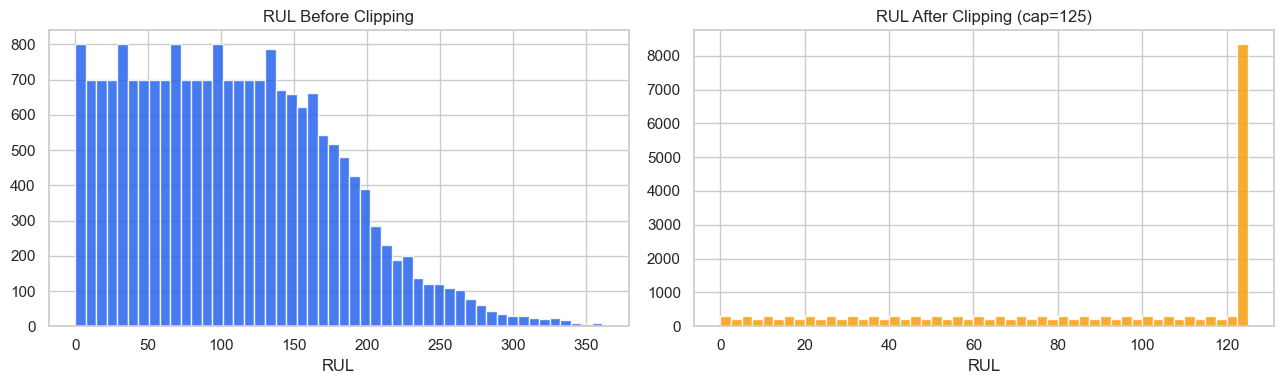

In [4]:
max_cycle_by_engine = train_df.groupby("unit_id")["cycle"].max().rename("max_cycle")
train_df = train_df.join(max_cycle_by_engine, on="unit_id")
train_df["RUL_raw"] = train_df["max_cycle"] - train_df["cycle"]
train_df["RUL"] = train_df["RUL_raw"].clip(upper=RUL_CAP)
train_df = train_df.drop(columns=["max_cycle"])

# Sanity checks: RUL should decrease with cycle and should not be constant.
example_engine = int(train_df["unit_id"].iloc[0])
engine_view = train_df[train_df["unit_id"] == example_engine].sort_values("cycle")
is_nonincreasing = np.all(np.diff(engine_view["RUL_raw"].values) <= 0)

print("RUL non-increasing for sample engine:", is_nonincreasing)
print("RUL unique values:", train_df["RUL"].nunique())
print("RUL min/max:", float(train_df["RUL"].min()), float(train_df["RUL"].max()))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(train_df["RUL_raw"], bins=50, color="#2563eb", alpha=0.85)
axes[0].set_title("RUL Before Clipping")
axes[0].set_xlabel("RUL")

axes[1].hist(train_df["RUL"], bins=50, color="#f59e0b", alpha=0.85)
axes[1].set_title("RUL After Clipping (cap=125)")
axes[1].set_xlabel("RUL")

plt.tight_layout()
plt.show()

In [5]:
# Scale only input features. Do not scale target RUL.
scaler = MinMaxScaler()
train_df[feature_cols] = train_df[feature_cols].astype(float)
test_df[feature_cols] = test_df[feature_cols].astype(float)

train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
test_df[feature_cols] = scaler.transform(test_df[feature_cols])

with open(PROCESSED_DIR / "feature_scaler.pkl", "wb") as fp:
    pickle.dump(scaler, fp)

train_df[feature_cols].describe().T.head()

,count,mean,std,min,25%,50%,75%,max
sensor_2,20631.0,0.443052,0.150618,0.0,0.335843,0.430723,0.539157,1.0
sensor_3,20631.0,0.424746,0.133664,0.0,0.331807,0.415522,0.508829,1.0
sensor_4,20631.0,0.450435,0.151935,0.0,0.339467,0.435348,0.545324,1.0
sensor_7,20631.0,0.566459,0.142527,0.0,0.476651,0.578100,0.669887,1.0
sensor_8,20631.0,0.297957,0.107554,0.0,0.227273,0.287879,0.363636,1.0


In [6]:
def build_train_sequences(df: pd.DataFrame, seq_len: int):
    X, y, unit_ids = [], [], []
    
    for unit_id in df["unit_id"].unique():
        engine_data = df[df["unit_id"] == unit_id].sort_values("cycle")
        features = engine_data[feature_cols].values
        rul = engine_data["RUL"].values

        for i in range(len(features) - seq_len + 1):
            X.append(features[i:i + seq_len])
            y.append(rul[i + seq_len - 1])
            unit_ids.append(unit_id)

    return np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.float32), np.asarray(unit_ids, dtype=np.int32)


def build_test_last_sequences(df: pd.DataFrame, rul_table: pd.DataFrame, seq_len: int):
    X_test, y_test, test_units = [], [], []
    final_rul_map = {i + 1: v for i, v in enumerate(rul_table["final_rul"].tolist())}

    for unit_id in df["unit_id"].unique():
        engine_data = df[df["unit_id"] == unit_id].sort_values("cycle")
        features = engine_data[feature_cols].values

        if len(features) < seq_len:
            pad = np.repeat(features[[0]], seq_len - len(features), axis=0)
            features = np.vstack([pad, features])

        X_test.append(features[-seq_len:])
        y_test.append(float(final_rul_map[unit_id]))
        test_units.append(unit_id)

    return np.asarray(X_test, dtype=np.float32), np.asarray(y_test, dtype=np.float32), np.asarray(test_units, dtype=np.int32)

In [7]:
X_train, y_train, train_unit_ids = build_train_sequences(train_df, SEQ_LEN)
X_test, y_test, test_unit_ids = build_test_last_sequences(test_df, rul_df, SEQ_LEN)

np.save(PROCESSED_DIR / "X_train_sequences.npy", X_train)
np.save(PROCESSED_DIR / "y_train_sequences.npy", y_train)
np.save(PROCESSED_DIR / "train_sequence_unit_ids.npy", train_unit_ids)
np.save(PROCESSED_DIR / "X_test_last.npy", X_test)
np.save(PROCESSED_DIR / "y_test_last.npy", y_test)
np.save(PROCESSED_DIR / "test_unit_ids.npy", test_unit_ids)

with open(PROCESSED_DIR / "feature_columns.json", "w", encoding="utf-8") as fp:
    json.dump(feature_cols, fp, indent=2)

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test:", X_test.shape, "| y_test:", y_test.shape)
print("Train target std:", float(np.std(y_train)))

X_train: (17731, 30, 14) | y_train: (17731,)
X_test: (100, 30, 14) | y_test: (100,)
Train target std: 41.79997253417969


In [8]:
# Build per-cycle trajectory windows for evaluation and inference demo.
final_rul_map = {i + 1: v for i, v in enumerate(rul_df["final_rul"].tolist())}
test_trajectories = {}

for unit_id in test_df["unit_id"].unique():
    engine_data = test_df[test_df["unit_id"] == unit_id].sort_values("cycle").copy()
    max_cycle_obs = int(engine_data["cycle"].max())
    engine_data["actual_rul"] = (max_cycle_obs - engine_data["cycle"]) + final_rul_map[unit_id]

    seqs, actuals, cycles = [], [], []
    features = engine_data[feature_cols].to_numpy(dtype=np.float32)
    actual_rul = engine_data["actual_rul"].to_numpy(dtype=np.float32)
    cyc = engine_data["cycle"].to_numpy(dtype=np.int32)

    for i in range(len(engine_data)):
        window = features[max(0, i - SEQ_LEN + 1): i + 1]
        if len(window) < SEQ_LEN:
            pad = np.repeat(window[[0]], SEQ_LEN - len(window), axis=0)
            window = np.vstack([pad, window])
        seqs.append(window.astype(np.float32))
        actuals.append(float(actual_rul[i]))
        cycles.append(int(cyc[i]))

    test_trajectories[int(unit_id)] = {
        "cycles": cycles,
        "actual_rul": actuals,
        "sequences": np.asarray(seqs, dtype=np.float32),
        "final_rul": float(final_rul_map[unit_id]),
    }

with open(PROCESSED_DIR / "test_engine_trajectories.pkl", "wb") as fp:
    pickle.dump(test_trajectories, fp)

sample_count = min(100, len(X_test))
with open(PROCESSED_DIR / "test_sequences_sample.json", "w", encoding="utf-8") as fp:
    json.dump({"samples": X_test[:sample_count].tolist()}, fp)

print("Saved trajectory file and frontend sample JSON.")

Saved trajectory file and frontend sample JSON.


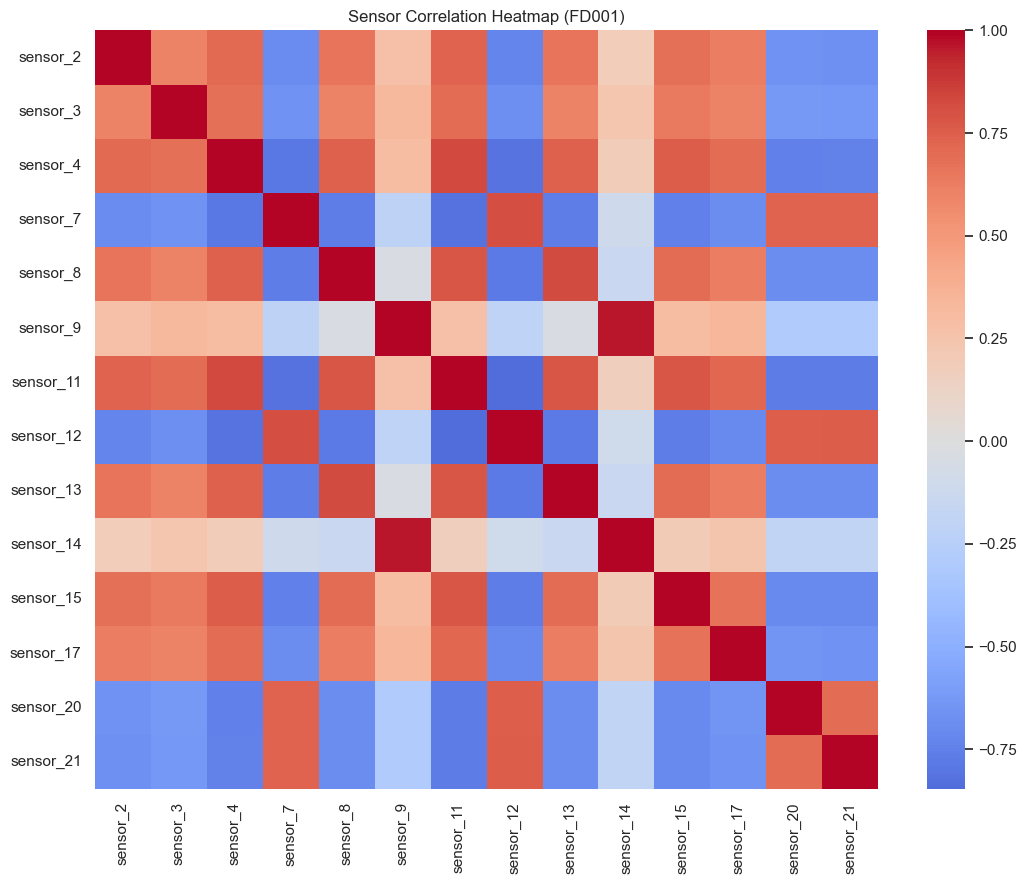

In [9]:
corr = train_df[feature_cols].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Sensor Correlation Heatmap (FD001)")
plt.tight_layout()
plt.show()

### Done

Pipeline checks are complete and processed artifacts are saved in `data/processed/`.